**3 варіант**

1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 19, 20, 21, 23, 25, 27


In [23]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "NationalNames.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kaggle/us-baby-names",
  file_path
)


print(df.head())

print("First 5 records:", df.head())

/tmp/ipykernel_366/2643921957.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'us-baby-names' dataset.
   Id       Name  Year Gender  Count
0   1       Mary  1880      F   7065
1   2       Anna  1880      F   2604
2   3       Emma  1880      F   2003
3   4  Elizabeth  1880      F   1939
4   5     Minnie  1880      F   1746
First 5 records:    Id       Name  Year Gender  Count
0   1       Mary  1880      F   7065
1   2       Anna  1880      F   2604
2   3       Emma  1880      F   2003
3   4  Elizabeth  1880      F   1939
4   5     Minnie  1880      F   1746


In [4]:
import pandas as pd
import numpy as np

1. Виведіть перші 8 рядків набору даних.

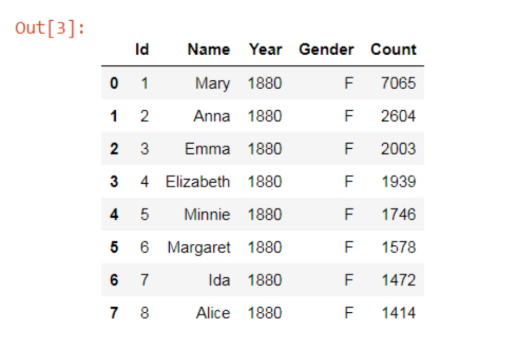

In [7]:
df[0:8]

,Id,Name,Year,Gender,Count
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746
5,6,Margaret,1880,F,1578
6,7,Ida,1880,F,1472
7,8,Alice,1880,F,1414


2. Вивести останні 8 рядків набору даних.

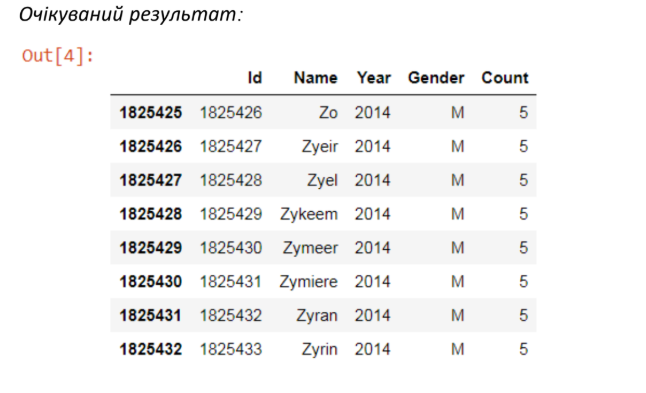

In [11]:
df[-8:]

,Id,Name,Year,Gender,Count
1825425,1825426,Zo,2014,M,5
1825426,1825427,Zyeir,2014,M,5
1825427,1825428,Zyel,2014,M,5
1825428,1825429,Zykeem,2014,M,5
1825429,1825430,Zymeer,2014,M,5
1825430,1825431,Zymiere,2014,M,5
1825431,1825432,Zyran,2014,M,5
1825432,1825433,Zyrin,2014,M,5


4. Отримайте загальну інформацію про дані у наборі даних.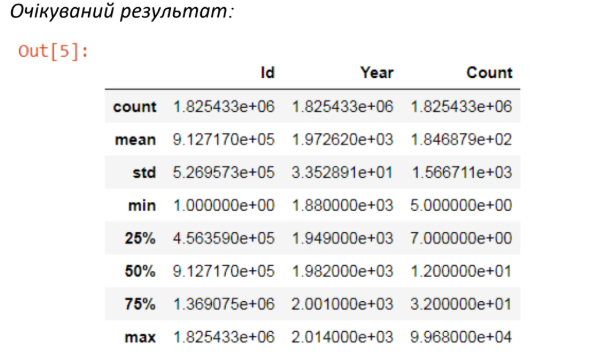

In [18]:

df[['Id', 'Year','Count']].describe()


,Id,Year,Count
count,1.825433e+06,1.825433e+06,1.825433e+06
mean,9.127170e+05,1.972620e+03,1.846879e+02
std,5.269573e+05,3.352891e+01,1.566711e+03
min,1.000000e+00,1.880000e+03,5.000000e+00
25%,4.563590e+05,1.949000e+03,7.000000e+00
50%,9.127170e+05,1.982000e+03,1.200000e+01
75%,1.369075e+06,2.001000e+03,3.200000e+01
max,1.825433e+06,2.014000e+03,9.968000e+04


5. Знайдіть кількість унікальних імен у наборі даних
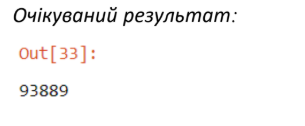

In [22]:
df['Name'].nunique()

93889

6. Обчисліть кількість унікальних жіночих та чоловічих імен у цілому
наборі даних
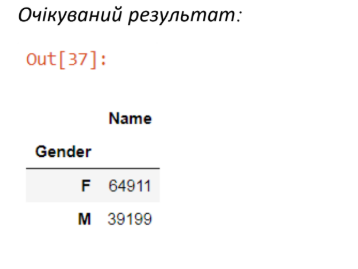

In [25]:
df.groupby('Gender')['Name'].nunique()

,Name
Gender,
F,64911
M,39199


7. Знайдіть 5 найпопулярніших чоловічих імен у 2010 році
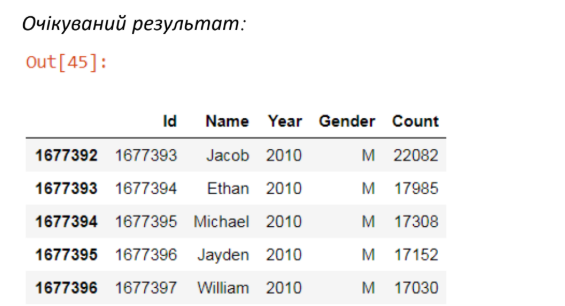

In [32]:
df[(df['Year'] == 2010)&(df['Gender'] == 'M')].nlargest(5, 'Count')

,Id,Name,Year,Gender,Count
1677392,1677393,Jacob,2010,M,22082
1677393,1677394,Ethan,2010,M,17985
1677394,1677395,Michael,2010,M,17308
1677395,1677396,Jayden,2010,M,17152
1677396,1677397,William,2010,M,17030


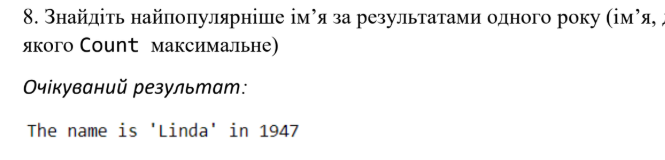

In [40]:
name=df.nlargest(1, 'Count')['Name'].values[0]
year=df.nlargest(1, 'Count')['Year'].values[0]
print(f"Найпопулярніше ім'я '{name}' в {year}")



Найпопулярніше ім'я 'Linda' в 1947


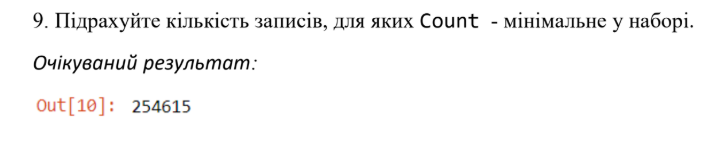

In [46]:
len(df[df['Count'] == df['Count'].min()])

254615

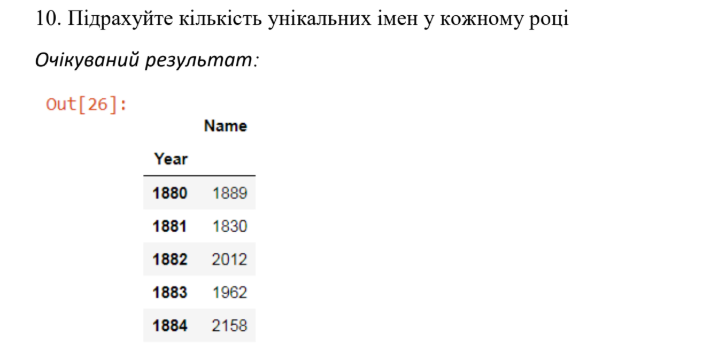

In [47]:
df.groupby('Year')['Name'].nunique()

,Name
Year,
1880,1889
1881,1830
1882,2012
1883,1962
1884,2158
...,...
2010,31603
2011,31418
2012,31236


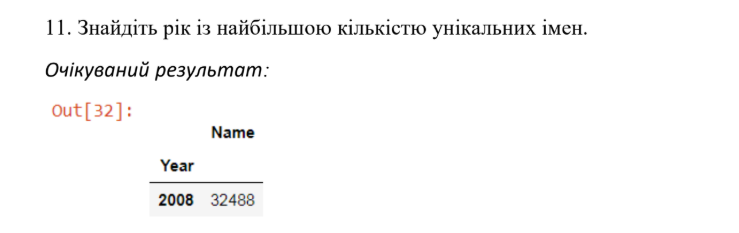

In [50]:
df.groupby('Year')['Name'].nunique().nlargest(1)

,Name
Year,
2008,32488


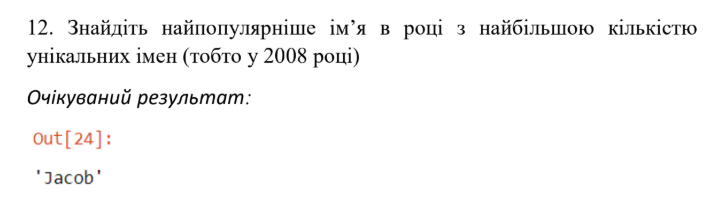

In [55]:
df[df['Year'] == 2008].nlargest(1, 'Count')['Name'].iloc[0]

'Jacob'

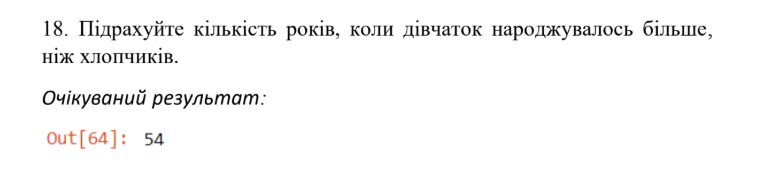

In [57]:
g= df.groupby(['Year', 'Gender'])['Count'].sum().unstack()
y = (g['F'] > g['M']).sum()
print(y)

54


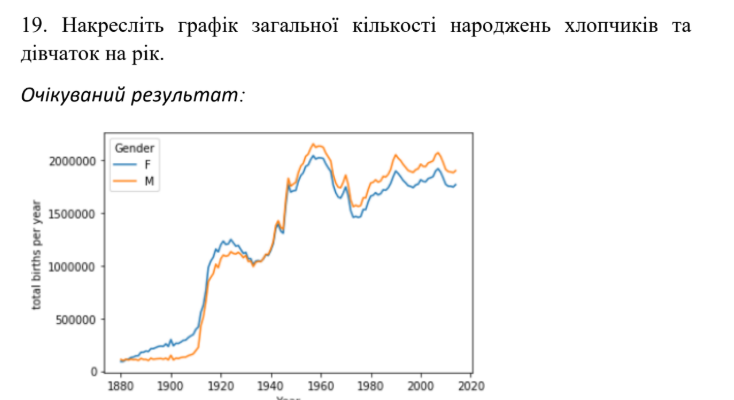

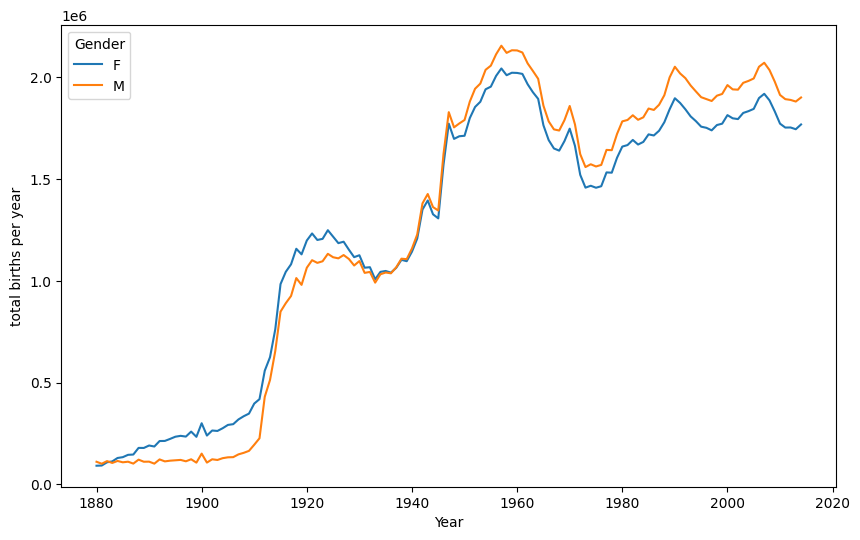

In [58]:
import matplotlib.pyplot as plt

d = df.groupby(['Year', 'Gender'])['Count'].sum().unstack()
d.plot(figsize=(10, 6))
plt.ylabel('total births per year')
plt.xlabel('Year')
plt.legend(title='Gender')
plt.show()

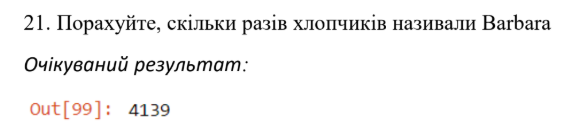

In [64]:
df[(df['Name'] == 'Barbara') & (df['Gender'] == 'M')]['Count'].sum()

np.int64(4139)

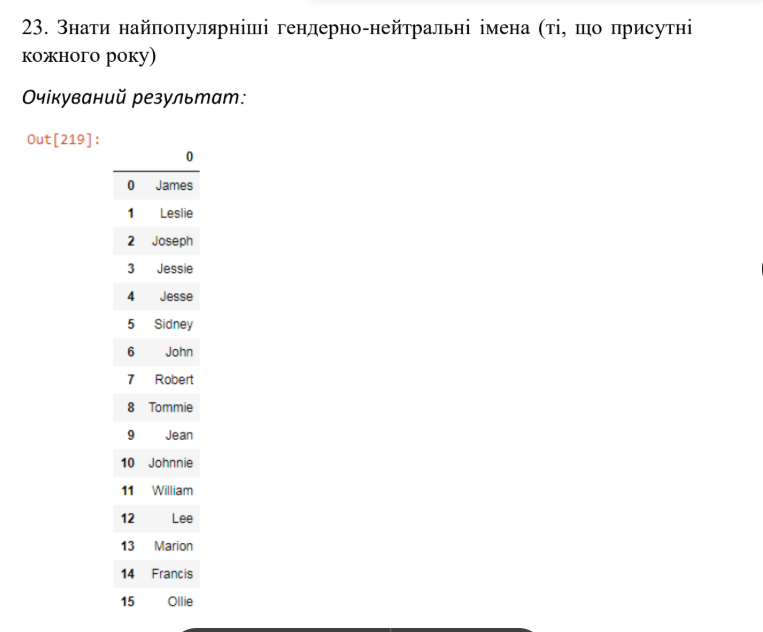

In [71]:
years = df['Year'].nunique()
n=df.groupby(['Name', 'Gender'])['Year'].nunique().unstack()
n2=n[(n['F']==years)&(n['M']==years)].index.to_frame(index=False)
n2

,Name
0,Francis
1,James
2,Jean
3,Jesse
4,Jessie
5,John
6,Johnnie
7,Joseph
8,Lee
9,Leslie


25. Побудувати графіки розподілення кількості імен John та Mary по
роках без залежності до статі.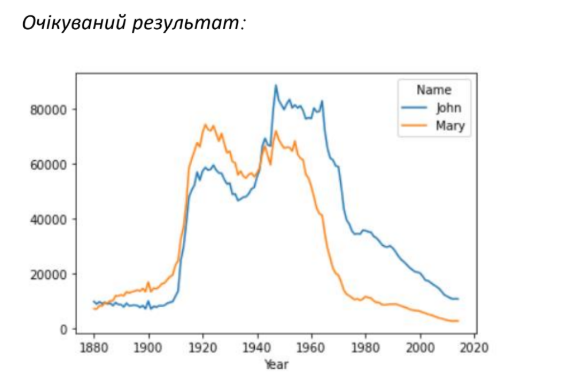

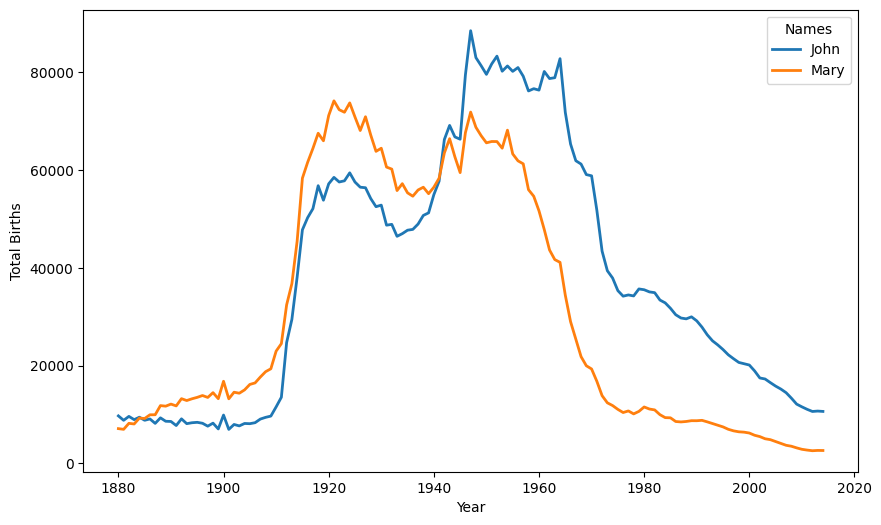

In [72]:
subset = df[df['Name'].isin(['John', 'Mary'])]
plot = subset.groupby(['Year', 'Name'])['Count'].sum().unstack()
plot.plot(figsize=(10, 6), linewidth=2)
plt.xlabel('Year')
plt.ylabel('Total Births')
plt.legend(title='Names')
plt.show()

27. Знайти найпопулярніші імена в кожному році.
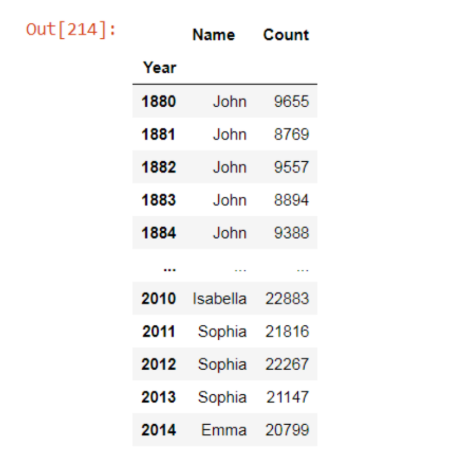

In [79]:
df.loc[df.groupby('Year')['Count'].idxmax()].set_index('Year')[['Name', 'Count']]

,Name,Count
Year,,
1880,John,9655
1881,John,8769
1882,John,9557
1883,John,8894
1884,John,9388
...,...,...
2010,Isabella,22883
2011,Sophia,21816
2012,Sophia,22267
